# Yield Simulator for W2W Hybrid Bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [38]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator

UCIe standard criticality file saved in  pad_bitmap/UCIe_standard_criticality.txt
redundant_net_to_bumpids: {'txdatasb': {0, 5}, 'txcksb': {1, 4}, 'vccaon': {2, 3}, 'vccio': {66, 69, 6, 7, 8, 9, 10, 11, 18, 54, 57}, 'vss': {12, 13, 14, 15, 16, 17, 23, 30, 31, 32, 33, 34, 35, 42, 45, 48, 49, 50, 51, 52, 53, 67, 68, 70, 71, 78, 81}, 'txdata7': {19}, 'txdata9': {20}, 'rxdata8': {21}, 'rxdata6': {22}, 'txdata5': {24}, 'txckn': {25}, 'txdata11': {26}, 'rxdata10': {27}, 'rxckp': {28}, 'rxdata4': {29}, 'txdata4': {36}, 'txckp': {37}, 'txdata10': {38}, 'rxdata11': {39}, 'rxckn': {40}, 'rxdata5': {41}, 'txdata6': {43}, 'txdata8': {44}, 'rxdata9': {46}, 'rxdata7': {47}, 'txdata3': {55}, 'txdata13': {56}, 'rxdata12': {58}, 'rxdata2': {59}, 'txdata1': {60}, 'txvld': {61}, 'txdata15': {62}, 'rxdata13': {82, 63}, 'rxtrk': {64}, 'rxdata0': {65}, 'txdata0': {72}, 'txtrk': {73}, 'txdata14': {74}, 'rxdata15': {75}, 'rxvld': {76}, 'rxdata1': {77}, 'txdata2': {79}, 'txdata12': {80}, 'rxdata3': {83}}
Pad b

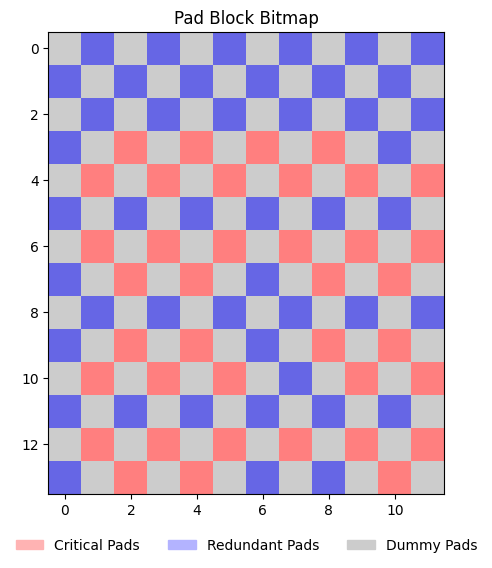

Processing wafer 1/1..., Current mean yield is 95.83%.
The assembly yield is 95.83%.
Assembly yield for point 1: 95.8333%
Total time taken: 38.57 seconds


In [ ]:
# Load configuration
cfg = load_modeling_config(path='configs/config.yaml', 
                     mode='w2w_simulation',
                     debug=False)

# Generate pad bitmap collection
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                     blox_bmap_path='pad_bitmap/UCIe_standard.bmap', 
                                                     pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)
start_time = time.time()
# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='w2w_simulation')

assembly_yield, single_config_yield_list = Assembly_Yield_Simulator(
    cfg=cfg,
    pad_bitmap_collection=pad_bitmap_collection,                                    
)                                                       
print("Assembly Yield: {:.6f}".format(assembly_yield))
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))

In [ ]:
np.save('sim_df_yield_list_pd_-10_-8d1_size_1e4_300params_200dim.npy', assembly_yield_list)

[0.6678631229177094,
 0.6668266431792271,
 0.6681962771193644,
 0.663606152563229,
 0.6633100154950913,
 0.6654570092390901,
 0.6638652724978494,
 0.6618663472879195,
 0.6645685980346768,
 0.6621624843560574]

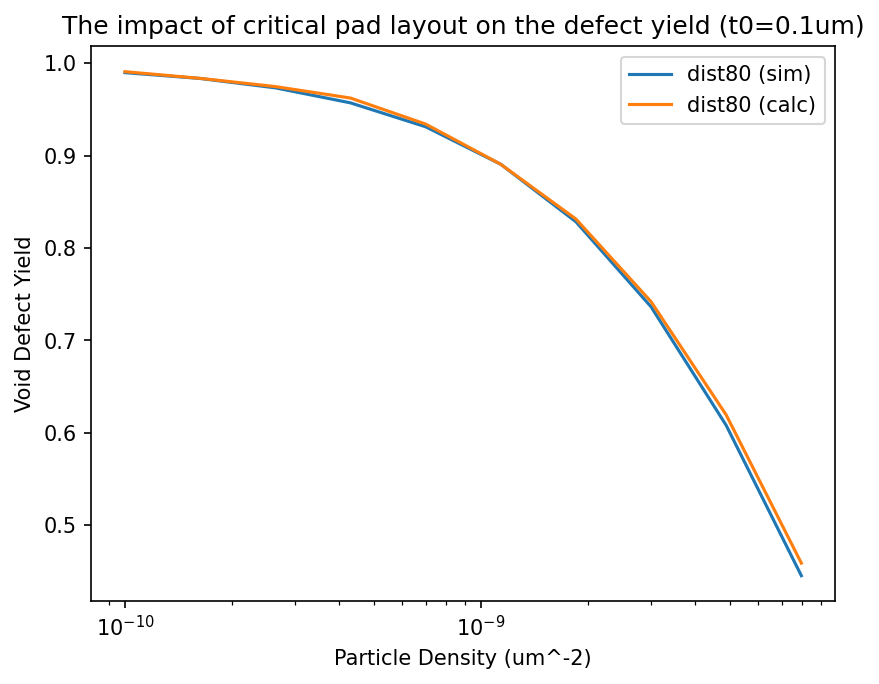

In [ ]:
particle_density_list = np.logspace(-10, -8.1, 10)
redundant_2copy_yield_dist80_critical_simulate = [0.9898717150057933,
 0.9835840362219836,
 0.9734456446297147,
 0.9571835960590951,
 0.9313200288008368,
 0.8907502895065961,
 0.8285237929258553,
 0.7364898897985741,
 0.608160052042089,
 0.44547230967179824]
redundant_2copy_yield_dist80_critical_calculate = [0.9909259259259258,
 0.9837037037037037,
 0.9748148148148147,
 0.9624074074074075,
 0.9342592592592593,
 0.8907407407407408,
 0.8314814814814815,
 0.742037037037037,
 0.6194444444444445,
 0.4590740740740741]
redundant_2copy_yield_dist80_critical_simulate = np.array(redundant_2copy_yield_dist80_critical_simulate)
redundant_2copy_yield_dist80_critical_calculate = np.array(redundant_2copy_yield_dist80_critical_calculate)
# plot the calculated yield vs. the simulated yield
plt.figure(dpi=150)
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_simulate, label='dist80 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_calculate, label='dist80 (calc)')
plt.xscale('log')
plt.xlabel('Particle Density (um^-2)')
plt.ylabel('Void Defect Yield')
plt.title('The impact of critical pad layout on the defect yield (t0=0.1um)')
plt.legend()
plt.show()


### Y_sim v.s. Y_calc -> pad_block_size = 200 um

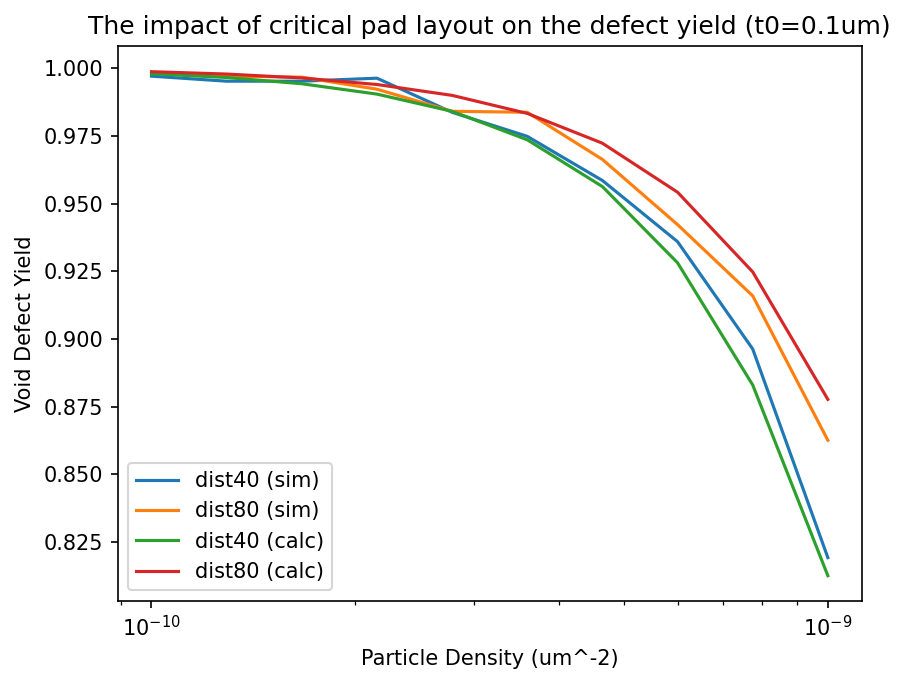

In [ ]:
particle_density_list = np.logspace(-10, -9, 10)
redundant_2copy_yield_dist40_critical_simulate = [0.9970370370370372,
 0.9951851851851853,
 0.9951851851851851,
 0.9962962962962963,
 0.9837037037037037,
 0.9748148148148148,
 0.9585185185185185,
 0.9359259259259259,
 0.8962962962962964,
 0.8192592592592594]
redundant_2copy_yield_dist80_critical_simulate = [0.9981481481481481,
 0.9970370370370369,
 0.9966666666666667,
 0.9922222222222221,
 0.984074074074074,
 0.9837037037037037,
 0.9662962962962963,
 0.9422222222222223,
 0.915925925925926,
 0.8625925925925927]
redundant_2copy_yield_dist40_critical_calculate = [0.9979268444252244,
 0.9965441635793376,
 0.9942419748401686,
 0.9904135217896465,
 0.9840600547330917,
 0.973552401638131,
 0.9562736659018274,
 0.928130727641162,
 0.8830164770269793,
 0.8125882513306562]
redundant_2copy_yield_dist80_critical_calculate = [0.9986962328735638,
 0.9978261326761374,
 0.996376404681686,
 0.9939627983089665,
 0.989949663997837,
 0.9832913772390017,
 0.9722841928175462,
 0.9541966166159586,
 0.9247704073078236,
 0.8776900402331577]
# redundant_2copy_yield_dist20_critical_simulate = np.array(redundant_2copy_yield_dist20_critical_simulate)
redundant_2copy_yield_dist40_critical_simulate = np.array(redundant_2copy_yield_dist40_critical_simulate)
redundant_2copy_yield_dist80_critical_simulate = np.array(redundant_2copy_yield_dist80_critical_simulate)
# redundant_2copy_yield_dist20_critical_calculate = np.array(redundant_2copy_yield_dist20_critical_calculate)
redundant_2copy_yield_dist40_critical_calculate = np.array(redundant_2copy_yield_dist40_critical_calculate)
redundant_2copy_yield_dist80_critical_calculate = np.array(redundant_2copy_yield_dist80_critical_calculate)
# redundant_2copy_yield_dist120_critical_calculate = np.array(redundant_2copy_yield_dist120_critical_calculate)
# plot the calculated yield vs. the simulated yield
plt.figure(dpi=150)
# plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_simulate, label='dist20 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_simulate, label='dist40 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_simulate, label='dist80 (sim)')
# plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_simulate, label='dist120 (sim)')
# plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_calculate, label='dist20 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_calculate, label='dist40 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_calculate, label='dist80 (calc)')
# plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_calculate, label='dist120 (calc)')
plt.xscale('log')
plt.xlabel('Particle Density (um^-2)')
plt.ylabel('Void Defect Yield')
plt.title('The impact of critical pad layout on the defect yield (t0=0.1um)')
plt.legend()
plt.show()


### Y_sim v.s. Y_calc -> pad_block_size = 400 um

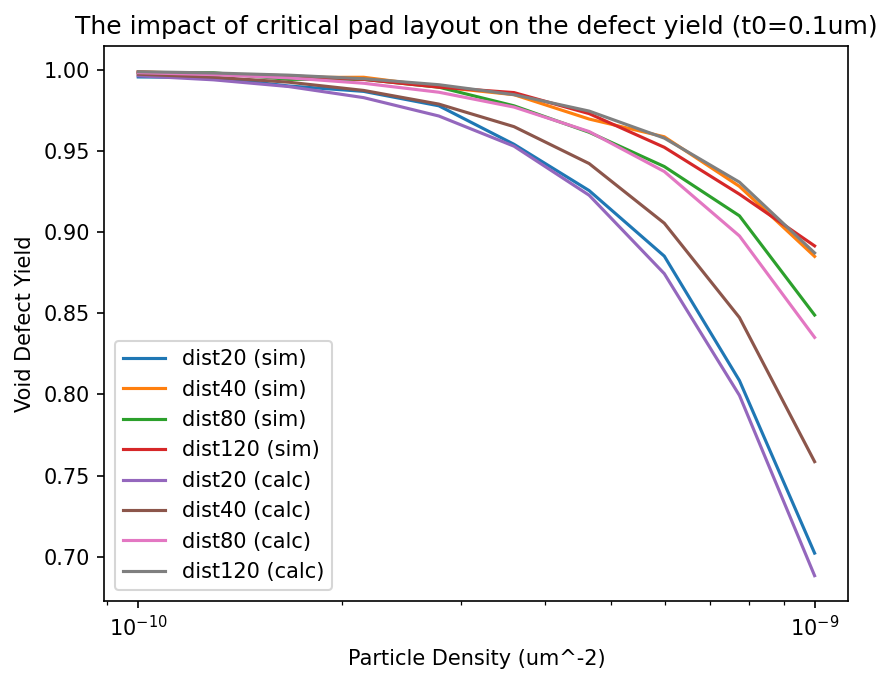

In [ ]:
particle_density_list = np.logspace(-10, -9, 10)
redundant_2copy_yield_dist20_critical_simulate = [0.9955555555555555,
 0.9951851851851853,
 0.9899999999999999,
 0.9866666666666666,
 0.9777777777777776,
 0.9540740740740741,
 0.9255555555555555,
 0.8851851851851851,
 0.8085185185185185,
 0.7022222222222221]
redundant_2copy_yield_dist40_critical_simulate = [0.9987037037037038,
 0.9974074074074075,
 0.9951851851851851,
 0.9953703703703702,
 0.9894444444444443,
 0.9846296296296295,
 0.9696296296296296,
 0.9587037037037037,
 0.9281481481481482,
 0.885]
redundant_2copy_yield_dist80_critical_simulate = [0.9981481481481481,
 0.9981481481481481,
 0.9940740740740741,
 0.9940740740740741,
 0.9892592592592593,
 0.9777777777777776,
 0.9614814814814816,
 0.9403703703703703,
 0.9100000000000001,
 0.8488888888888889]
redundant_2copy_yield_dist120_critical_simulate = [0.9985185185185184,
 0.9974074074074075,
 0.9962962962962963,
 0.994074074074074,
 0.9892592592592593,
 0.9859259259259259,
 0.9729629629629629,
 0.9522222222222222,
 0.9233333333333332,
 0.8914814814814814]
redundant_2copy_yield_dist20_critical_calculate = [0.9962719706268514,
 0.9937890198858643,
 0.9896609713716195,
 0.9828130944857648,
 0.9714954283081776,
 0.9529057049927289,
 0.922684387438409,
 0.8743899907397026,
 0.7993893819204969,
 0.688321275800331]
redundant_2copy_yield_dist40_critical_calculate = [0.9972405468188179,
 0.9954011990317654,
 0.9923405284682401,
 0.9872559504564457,
 0.978832272329579,
 0.964940370269552,
 0.9422046349936692,
 0.9054649732314973,
 0.8473397577488223,
 0.7585650298472465]
redundant_2copy_yield_dist80_critical_calculate = [0.9981998313899894,
 0.9969989438960519,
 0.9949989569652272,
 0.9916717016993505,
 0.9861462465825459,
 0.9769976582449255,
 0.9619253718696205,
 0.9372989418683182,
 0.8976145590805416,
 0.8351206395453719]
redundant_2copy_yield_dist120_critical_calculate = [0.9988033526970544,
 0.9980046700297118,
 0.996673808015505,
 0.9944577445723927,
 0.9907720874491673,
 0.9846544132303667,
 0.9745334626951304,
 0.9578816704657115,
 0.9307355630722097,
 0.8871542724446094]
redundant_2copy_yield_dist20_critical_simulate = np.array(redundant_2copy_yield_dist20_critical_simulate)
redundant_2copy_yield_dist40_critical_simulate = np.array(redundant_2copy_yield_dist40_critical_simulate)
redundant_2copy_yield_dist80_critical_simulate = np.array(redundant_2copy_yield_dist80_critical_simulate)
redundant_2copy_yield_dist20_critical_calculate = np.array(redundant_2copy_yield_dist20_critical_calculate)
redundant_2copy_yield_dist40_critical_calculate = np.array(redundant_2copy_yield_dist40_critical_calculate)
redundant_2copy_yield_dist80_critical_calculate = np.array(redundant_2copy_yield_dist80_critical_calculate)
redundant_2copy_yield_dist120_critical_calculate = np.array(redundant_2copy_yield_dist120_critical_calculate)
# plot the calculated yield vs. the simulated yield
plt.figure(dpi=150)
plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_simulate, label='dist20 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_simulate, label='dist40 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_simulate, label='dist80 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_simulate, label='dist120 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_calculate, label='dist20 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_calculate, label='dist40 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_calculate, label='dist80 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_calculate, label='dist120 (calc)')
plt.xscale('log')
plt.xlabel('Particle Density (um^-2)')
plt.ylabel('Void Defect Yield')
plt.title('The impact of critical pad layout on the defect yield (t0=0.1um)')
plt.legend()
plt.show()